In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from abc import ABC, abstractmethod
import matplotlib.pyplot as plt

In [2]:
## defining different classes for the differect oracles

class DeutschJozsaOracle(ABC):
    """Abstract base class for different oracle implementations"""
    # def init_auxiliary(self, circuit, qubits):
    #     circuit.x(qubits[1])
    #     circuit.h(qubits[1])
    @abstractmethod
    def apply_oracle(self, circuit, qubits):
        """Apply the oracle operation to the circuit"""
        pass

class Constant0Oracle(DeutschJozsaOracle):
    """Oracle that always returns 0"""
    def apply_oracle(self, circuit, qubits):
        # Do nothing - identity operation
        # self.init_auxiliary(circuit, qubits)
        pass

class Constant1Oracle(DeutschJozsaOracle):
    """Oracle that always returns 1"""
    def apply_oracle(self, circuit, qubits):
        # self.init_auxiliary(circuit, qubits)
        # Apply X gate to auxiliary qubit
        circuit.x(qubits[1])

class IdentityOracle(DeutschJozsaOracle):
    def apply_oracle(self, circuit, qubits):
        # Just CNOT between Q1 and Q2
        circuit.cx(qubits[0], qubits[1])

class NotOracle(DeutschJozsaOracle):
    def apply_oracle(self, circuit, qubits):
        # NOT on input, CNOT, then NOT again
        circuit.x(qubits[0])
        circuit.cx(qubits[0], qubits[1])
        circuit.x(qubits[0])

In [3]:
## universal DJ Algorithm
class DeutschJozsaAlgorithm:
    """Main class implementing the Deutsch-Jozsa Algorithm"""
    
    def __init__(self, oracle: DeutschJozsaOracle):
        """Initialize with specific oracle implementation"""
        self.oracle = oracle
        
    def create_circuit(self):
        """Create the quantum circuit for the algorithm"""
        # Create registers
        q = QuantumRegister(2, 'q')
        c = ClassicalRegister(1, 'c')
        circuit = QuantumCircuit(q, c)
        
        # Initialize first qubit to |+⟩ and second to |1⟩
        circuit.x(q[1])
        circuit.h(q[0])
        circuit.h(q[1])
        
        # Apply oracle
        self.oracle.apply_oracle(circuit, q)
        
        # Final Hadamard on query qubit
        circuit.h(q[0])
        
        # Measure
        circuit.measure(q[0], c[0])     
        
        return circuit
    
    def run(self, shots=1024):
        """Run the algorithm and return results"""
        circuit = self.create_circuit()
        backend = AerSimulator()
        result = backend.run(circuit, shots=shots).result()
        counts = result.get_counts(circuit)
        return counts, circuit

In [4]:
oracles = {
    'Constant-0': Constant0Oracle(),
    'Constant-1': Constant1Oracle(),
    'Identity': IdentityOracle(),
    'NOT': NotOracle()
}

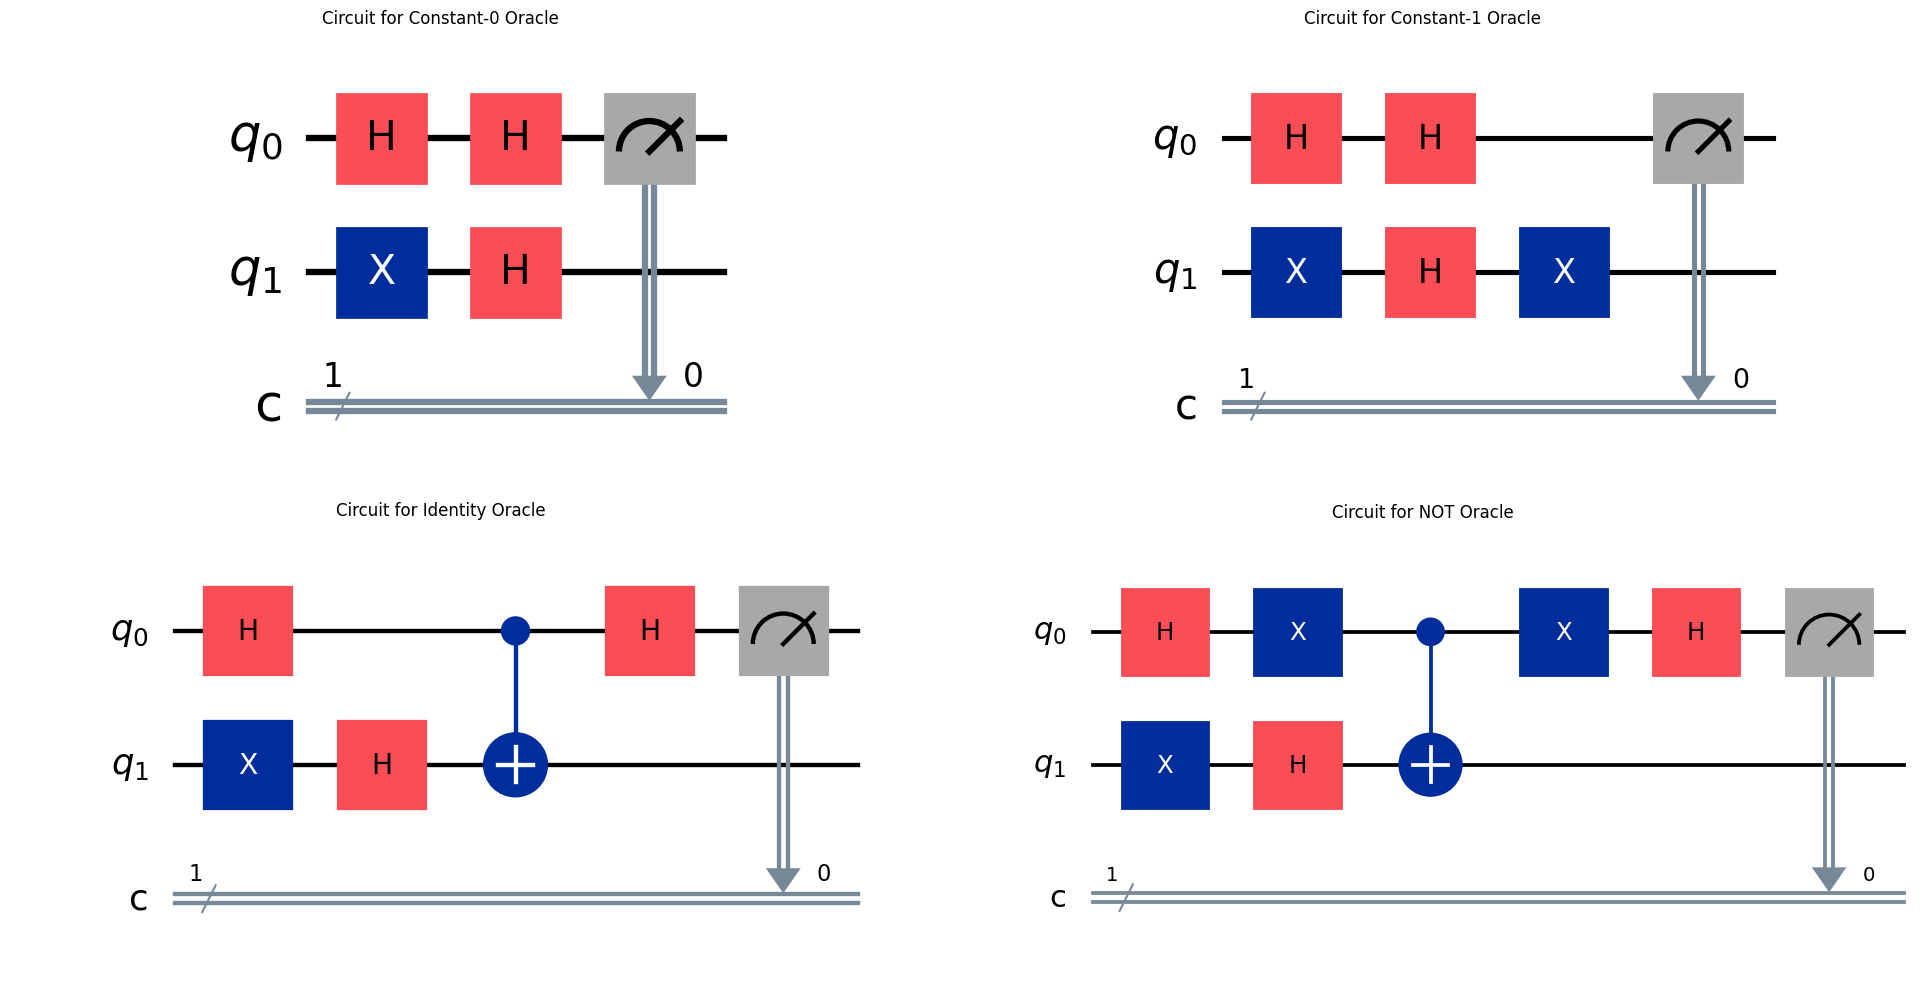

In [5]:
# Draw each oracle circuit separately
plt.figure(figsize=(20,10))
for i, (name, oracle) in enumerate(oracles.items(), 1):
    plt.subplot(2,2,i)
    algorithm = DeutschJozsaAlgorithm(oracle)
    circuit = algorithm.create_circuit()
    circuit.draw('mpl', ax=plt.gca())
    plt.title(f'Circuit for {name} Oracle')

plt.tight_layout()
plt.show()

In [8]:
all_results = {}
    
# create and run each case
for name, oracle in oracles.items():
    algorithm = DeutschJozsaAlgorithm(oracle)
    counts, circuit = algorithm.run()
    all_results[name] = {
        'counts': counts,
        'circuit': circuit
    }
    print(f"\nResults for {name}:")
    print(f"Measurement counts: {counts}")
    print("Circuit:")



Results for Constant-0:
Measurement counts: {'0': 1024}
Circuit:

Results for Constant-1:
Measurement counts: {'0': 1024}
Circuit:

Results for Identity:
Measurement counts: {'1': 1024}
Circuit:

Results for NOT:
Measurement counts: {'1': 1024}
Circuit:


In [35]:
def run_test_case(oracle_type, shots=1024):
    algorithm = DeutschJozsaAlgorithm(oracle_type)
    counts, circuit = algorithm.run(shots=shots)
    
    # Add state vector simulation to see intermediate states
    backend = AerSimulator()
    # backend.set_options()
    backend.set_options(method='statevector')
    result = backend.run(circuit.copy(), shots=shots, memory=True).result()
    
    counts = result.get_counts(circuit)
    
    print(f"\nResults for {oracle_type.__class__.__name__}:")
    print(f"Measurement counts: {counts}")
    
    return counts, circuit

# Test each case
results = {}
for oracle in [Constant0Oracle(), Constant1Oracle(), IdentityOracle(), NotOracle()]:
    results[oracle.__class__.__name__] = run_test_case(oracle)


Results for Constant0Oracle:
Measurement counts: {'0': 1024}

Results for Constant1Oracle:
Measurement counts: {'0': 1024}

Results for IdentityOracle:
Measurement counts: {'1': 1024}

Results for NotOracle:
Measurement counts: {'1': 1024}
